In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Dataset extracted to: C:\Users\nlkhkghk\Fruits Classification\train
['Fruits Classification']
Found 9700 images belonging to 5 classes.
Found 200 images belonging to 5 classes.


C:\Users\nlkhkghk\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 191s 618ms/step - accuracy: 0.4701 - loss: 1.2464 - val_accuracy: 0.5750 - val_loss: 1.0730
Epoch 2/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 42s 138ms/step - accuracy: 0.5608 - loss: 1.0614 - val_accuracy: 0.6250 - val_loss: 0.9655
Epoch 3/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.6097 - loss: 0.9658 - val_accuracy: 0.6350 - val_loss: 0.9512
Epoch 4/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.6568 - loss: 0.8821 - val_accuracy: 0.6550 - val_loss: 0.8447
Epoch 5/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 42s 138ms/step - accuracy: 0.6829 - loss: 0.8269 - val_accuracy: 0.6550 - val_loss: 0.8386
Epoch 6/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 42s 138ms/step - accuracy: 0.7104 - loss: 0.7649 - val_accuracy: 0.6900 - val_loss: 0.8058
Epoch 7/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - accuracy: 0.7385 - loss: 0.6896 - val_accuracy: 0.6950 - val_loss: 0.7720
Epoch 8/15
304/304 ━━━━━━━━━━━━━━━━━━━━ 40s 133ms/step - accuracy: 0.7658 - loss: 

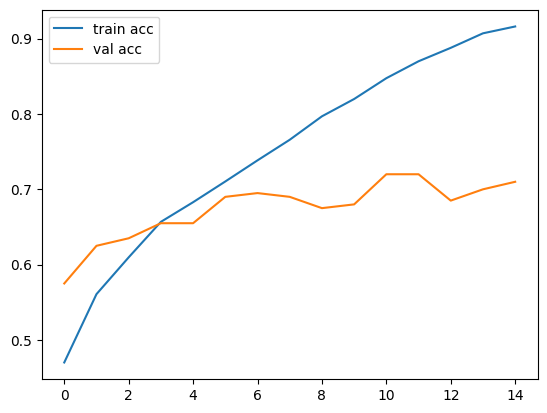

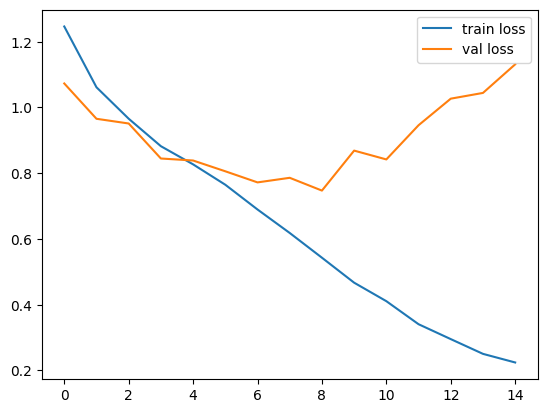

In [2]:
import zipfile
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Step 1: Unzip dataset
zip_path = r"C:\Users\nlkhkghk\Downloads\archive (3).zip"   # Path to your zip file
extract_path = r"C:\Users\nlkhkghk\Fruits Classification\train"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

# Step 2: Define image parameters
img_width, img_height = 100, 100
batch_size = 32

# Step 3: Create data generators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
print(os.listdir(extract_path))


train_generator = train_datagen.flow_from_directory(
    os.path.join(extract_path, 'Fruits Classification/train'),
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(extract_path, 'Fruits Classification/valid'),
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# Step 4: Build CNN model
# Step 4: Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')  # output layer
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor = "val_loss",
    patience = 3,
    restore_best_weights = True)
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

# Step 7: Plot accuracy and loss
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.show()
